# Fraud Detection — Random Forest with Time-Based Split

**Approach:**
1. Same feature engineering as the PCA model for a fair comparison
2. Time-based train/test split using `step` — prevents future data leaking into training
3. Random Forest with `balanced_subsample` to handle the 0.13% fraud class imbalance
4. Feature importance analysis + threshold tuning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, precision_recall_curve,
    roc_auc_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [2]:
df = pd.read_csv('Financial_Fraud_dataset.csv')
print(f"Full dataset shape: {df.shape}")
print(f"Overall fraud rate: {df['isFraud'].mean()*100:.4f}%")
print(f"\nStep range: {df['step'].min()} — {df['step'].max()}")

Full dataset shape: (6362620, 11)
Overall fraud rate: 0.1291%

Step range: 1 — 743


## 2. Feature Engineering

Identical to the PCA notebook so results are comparable.

In [3]:
# Filter to types where fraud occurs
df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
print(f"Filtered shape: {df.shape}")
print(f"Fraud rate after filter: {df['isFraud'].mean()*100:.4f}%")

# Encode transaction type (1 = TRANSFER, 0 = CASH_OUT)
df['type_encoded'] = (df['type'] == 'TRANSFER').astype(int)

# Balance discrepancy features — strongest fraud signals
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# Account drain: origin emptied after transaction
df['origDrained'] = ((df['newbalanceOrig'] == 0) & (df['oldbalanceOrg'] > 0)).astype(int)

# Destination balance unchanged despite receiving funds
df['destUnchanged'] = (df['newbalanceDest'] == df['oldbalanceDest']).astype(int)

# Log-transform amount
df['log_amount'] = np.log1p(df['amount'])

FEATURES = [
    'log_amount',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'errorBalanceOrig', 'errorBalanceDest',
    'origDrained', 'destUnchanged',
    'type_encoded'
]

print("\nFeature engineering complete.")

Filtered shape: (2770409, 11)
Fraud rate after filter: 0.2965%

Feature engineering complete.


In [18]:
print(df[df['isFraud']==0]['errorBalanceOrig'].value_counts())

errorBalanceOrig
 0.000000e+00    241822
 1.000000e-02      5936
-1.000000e-02      5878
 5.820766e-11      2115
-5.820766e-11      2086
                  ...  
 1.423723e+05         1
 1.074497e+05         1
 3.170075e+05         1
 1.822784e+04         1
 6.860445e+04         1
Name: count, Length: 2435392, dtype: int64


## 3. Time-Based Train/Test Split

**Why time-based?** A random split would let the model 'see' transactions from later time steps during training, which is unrealistic — in production, you always predict on future data. We use the `step` column as a proxy for time.

80% of steps → train, 20% → test.

In [4]:
split_step = int(df['step'].quantile(0.80))
print(f"Split at step {split_step}")
print(f"Train: steps 1–{split_step}")
print(f"Test:  steps {split_step+1}–{df['step'].max()}")

train_df = df[df['step'] <= split_step]
test_df  = df[df['step'] >  split_step]

X_train = train_df[FEATURES].values
y_train = train_df['isFraud'].values
X_test  = test_df[FEATURES].values
y_test  = test_df['isFraud'].values

print(f"\nTrain: {len(X_train):,} samples | Fraud: {y_train.sum():,} ({y_train.mean()*100:.4f}%)")
print(f"Test:  {len(X_test):,} samples  | Fraud: {y_test.sum():,} ({y_test.mean()*100:.4f}%)")

Split at step 354
Train: steps 1–354
Test:  steps 355–743

Train: 2,217,905 samples | Fraud: 3,955 (0.1783%)
Test:  552,504 samples  | Fraud: 4,258 (0.7707%)


## 4. Train Random Forest

Key hyperparameter choices:
- `class_weight='balanced_subsample'` — each tree's bootstrap sample is reweighted so fraud counts more, without globally oversampling
- `max_depth=20` — deep enough to capture complex patterns, bounded to reduce overfitting
- `n_jobs=-1` — use all CPU cores

## 4a. Hyperparameter Tuning — Grid Search

We test 3 values each for `max_depth` and `min_samples_leaf` (9 combinations total).
To avoid using the test set during tuning, we carve a validation slice out of the training data (last 20% of training steps). The best combination by PR-AUC is then used to train the final model.

In [5]:

# Carve validation slice from training data (last 20% of train steps)
val_split = int(train_df['step'].quantile(0.80))
search_train_df = train_df[train_df['step'] <= val_split]
search_val_df   = train_df[train_df['step'] >  val_split]

X_search_train = search_train_df[FEATURES].values
y_search_train = search_train_df['isFraud'].values
X_search_val   = search_val_df[FEATURES].values
y_search_val   = search_val_df['isFraud'].values

print(f"Search train: {len(X_search_train):,} samples | Fraud: {y_search_train.sum():,}")
print(f"Search val:   {len(X_search_val):,} samples  | Fraud: {y_search_val.sum():,}")

# Grid: 3 values per hyperparameter = 9 combinations
# None and 1 are sklearn defaults — included to show improvement from tuning
param_grid = {
    'max_depth':        [None, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

results = []
print("\nRunning grid search (9 combinations, 50 trees each for speed)...")
print("(* = sklearn default)\n")

for depth in param_grid['max_depth']:
    for leaf in param_grid['min_samples_leaf']:
        rf_search = RandomForestClassifier(
            n_estimators=50,
            max_depth=depth,
            min_samples_leaf=leaf,
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=42
        )
        rf_search.fit(X_search_train, y_search_train)
        val_proba = rf_search.predict_proba(X_search_val)[:, 1]
        pr_auc    = average_precision_score(y_search_val, val_proba)
        results.append({'max_depth': str(depth), 'min_samples_leaf': leaf, 'val_pr_auc': pr_auc})
        depth_label = 'None*' if depth is None else f'{depth:5d}'
        leaf_label  = f'{leaf}*' if leaf == 1 else f'{leaf} '
        print(f"  max_depth={depth_label}, min_samples_leaf={leaf_label}  ->  PR-AUC: {pr_auc:.4f}")

results_df = pd.DataFrame(results).sort_values('val_pr_auc', ascending=False)
best       = results_df.iloc[0]
best_depth = None if best['max_depth'] == 'None' else int(best['max_depth'])
best_leaf  = int(best['min_samples_leaf'])

print(f"\nBest combination: max_depth={best_depth}, min_samples_leaf={best_leaf}  (PR-AUC: {best['val_pr_auc']:.4f})")
print(results_df.to_string(index=False))


Search train: 1,780,544 samples | Fraud: 3,401
Search val:   437,361 samples  | Fraud: 554

Running grid search (9 combinations, 50 trees each for speed)...
(* = sklearn default)

  max_depth=None*, min_samples_leaf=1*  ->  PR-AUC: 1.0000
  max_depth=None*, min_samples_leaf=5   ->  PR-AUC: 1.0000
  max_depth=None*, min_samples_leaf=10   ->  PR-AUC: 1.0000
  max_depth=   10, min_samples_leaf=1*  ->  PR-AUC: 1.0000
  max_depth=   10, min_samples_leaf=5   ->  PR-AUC: 1.0000
  max_depth=   10, min_samples_leaf=10   ->  PR-AUC: 1.0000
  max_depth=   20, min_samples_leaf=1*  ->  PR-AUC: 1.0000
  max_depth=   20, min_samples_leaf=5   ->  PR-AUC: 1.0000
  max_depth=   20, min_samples_leaf=10   ->  PR-AUC: 1.0000

Best combination: max_depth=None, min_samples_leaf=1  (PR-AUC: 1.0000)
max_depth  min_samples_leaf  val_pr_auc
     None                 1         1.0
     None                 5         1.0
     None                10         1.0
       10                 1         1.0
       10     

In [6]:
# Final model uses 100 trees (vs 50 in grid search) — more trees = better performance
# Grid search used 50 for speed; now that we have the best hyperparameters we train fully
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=best_depth,
    min_samples_leaf=best_leaf,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=42
)

print(f"Training final Random Forest with best params: max_depth={best_depth}, min_samples_leaf={best_leaf}")
print("(This may take a few minutes on 2M+ rows)...")
rf.fit(X_train, y_train)
print("Training complete.")


Training final Random Forest with best params: max_depth=None, min_samples_leaf=1
(This may take a few minutes on 2M+ rows)...
Training complete.


## 5. Evaluate on Test Set

In [11]:
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

pr_auc  = average_precision_score(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

print("Classification Report (default 0.5 threshold):")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))
print(f"PR-AUC:  {pr_auc:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Classification Report (default 0.5 threshold):
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    548246
       Fraud       1.00      1.00      1.00      4258

    accuracy                           1.00    552504
   macro avg       1.00      1.00      1.00    552504
weighted avg       1.00      1.00      1.00    552504

PR-AUC:  1.0000
ROC-AUC: 1.0000


## 6a. Training vs Test Performance

Comparing metrics on the training set vs the test set reveals whether the model is overfitting (strong on train, weak on test) or generalizing well.

In [16]:
from sklearn.metrics import recall_score, precision_score

y_pred_train  = rf.predict(X_train)
y_proba_train = rf.predict_proba(X_train)[:, 1]

pr_auc_train  = average_precision_score(y_train, y_proba_train)
pr_auc_test   = average_precision_score(y_test,  y_proba)
roc_auc_train = roc_auc_score(y_train, y_proba_train)
roc_auc_test  = roc_auc_score(y_test,  y_proba)
f1_train      = f1_score(y_train, y_pred_train)
f1_test       = f1_score(y_test,  y_pred)
recall_train    = recall_score(y_train, y_pred_train)
recall_test     = recall_score(y_test,  y_pred)
precision_train = precision_score(y_train, y_pred_train)
precision_test  = precision_score(y_test,  y_pred)

print(f"{'Metric':<18} {'Train':>10} {'Test':>10} {'Diff':>10}")
print(f"{'─'*50}")
print(f"{'PR-AUC':<18} {pr_auc_train:>10.4f} {pr_auc_test:>10.4f} {pr_auc_test - pr_auc_train:>+10.4f}")
print(f"{'ROC-AUC':<18} {roc_auc_train:>10.4f} {roc_auc_test:>10.4f} {roc_auc_test - roc_auc_train:>+10.4f}")
print(f"{'Recall':<18} {recall_train:>10.4f} {recall_test:>10.4f} {recall_test - recall_train:>+10.4f}")
print(f"{'Precision':<18} {precision_train:>10.4f} {precision_test:>10.4f} {precision_test - precision_train:>+10.4f}")
print(f"{'F1':<18} {f1_train:>10.4f} {f1_test:>10.4f} {f1_test - f1_train:>+10.4f}")

roc_gap = roc_auc_train - roc_auc_test
print(f"\nNote: PR-AUC is higher on test because the test set has a higher fraud rate (0.77% vs 0.18%),")
print(f"which mechanically inflates PR-AUC — this is not a model quality issue.")
print(f"ROC-AUC gap (train - test): {roc_gap:+.4f} — {'model is generalizing well' if abs(roc_gap) < 0.05 else 'large gap — possible overfitting'}")


Metric                  Train       Test       Diff
──────────────────────────────────────────────────
PR-AUC                 1.0000     1.0000    -0.0000
ROC-AUC                1.0000     1.0000    -0.0000
Recall                 1.0000     0.9995    -0.0005
Precision              1.0000     1.0000    +0.0000
F1                     1.0000     0.9998    -0.0002

Note: PR-AUC is higher on test because the test set has a higher fraud rate (0.77% vs 0.18%),
which mechanically inflates PR-AUC — this is not a model quality issue.
ROC-AUC gap (train - test): +0.0000 — model is generalizing well


## 6. Confusion Matrix

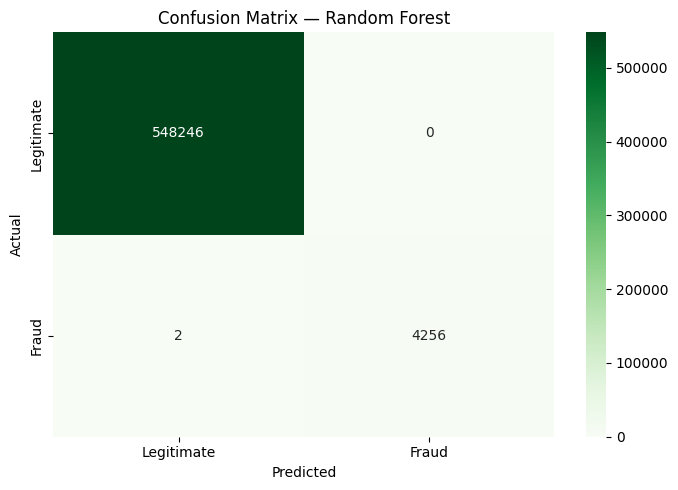

True Positives  (caught fraud):   4,256
False Negatives (missed fraud):   2
False Positives (false alarms):   0
True Negatives  (correct legit):  548,246

Recall (TPR):  0.9995  (fraud cases caught)
Precision:     1.0000  (of flagged, actually fraud)
TNR:           1.0000  (legit transactions correctly cleared)
FNR:           0.0005  (fraud cases missed)


In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (caught fraud):   {tp:,}")
print(f"False Negatives (missed fraud):   {fn:,}")
print(f"False Positives (false alarms):   {fp:,}")
print(f"True Negatives  (correct legit):  {tn:,}")
print(f"\nRecall (TPR):  {tp / (tp + fn):.4f}  (fraud cases caught)")
print(f"Precision:     {tp / (tp + fp):.4f}  (of flagged, actually fraud)")
print(f"TNR:           {tn / (tn + fp):.4f}  (legit transactions correctly cleared)")
print(f"FNR:           {fn / (fn + tp):.4f}  (fraud cases missed)")


## 7. Precision-Recall Curve & Threshold Tuning

We maximize recall subject to a minimum precision floor of 10% — meaning we're willing to flag up to 9 legitimate transactions for every fraud caught, but no worse.

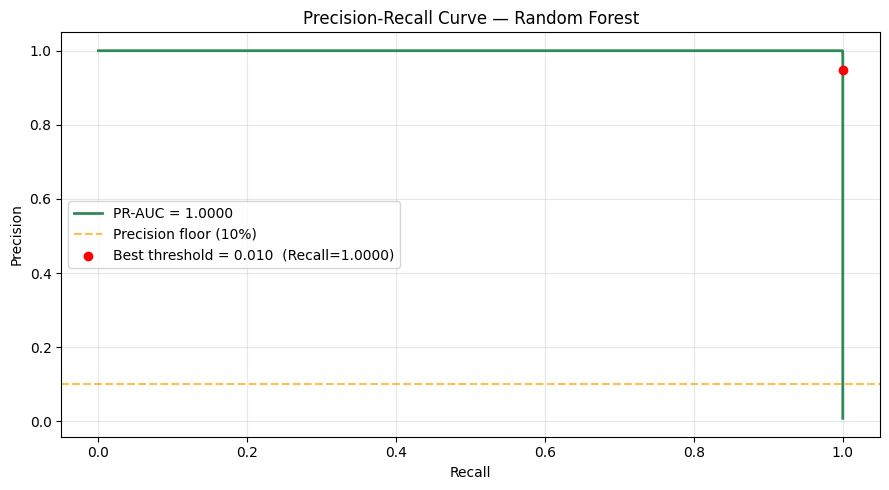

Optimal threshold: 0.0100
Recall at threshold:    1.0000
Precision at threshold: 0.9481

Classification Report at Optimal Threshold:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    548246
       Fraud       0.95      1.00      0.97      4258

    accuracy                           1.00    552504
   macro avg       0.97      1.00      0.99    552504
weighted avg       1.00      1.00      1.00    552504



In [13]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Maximize recall subject to precision >= 10%
PRECISION_FLOOR = 0.10
valid = precision[:-1] >= PRECISION_FLOOR
best_idx = np.argmax(recall[:-1] * valid)
best_thresh = thresholds[best_idx]

plt.figure(figsize=(9, 5))
plt.plot(recall, precision, color='seagreen', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
plt.axhline(y=PRECISION_FLOOR, color='orange', linestyle='--', alpha=0.7,
            label=f'Precision floor ({PRECISION_FLOOR:.0%})')
plt.scatter(recall[best_idx], precision[best_idx], color='red', zorder=5,
            label=f'Best threshold = {best_thresh:.3f}  (Recall={recall[best_idx]:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Random Forest')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal threshold: {best_thresh:.4f}")
print(f"Recall at threshold:    {recall[best_idx]:.4f}")
print(f"Precision at threshold: {precision[best_idx]:.4f}")

y_pred_opt = (y_proba >= best_thresh).astype(int)
print("\nClassification Report at Optimal Threshold:")
print(classification_report(y_test, y_pred_opt, target_names=['Legitimate', 'Fraud']))


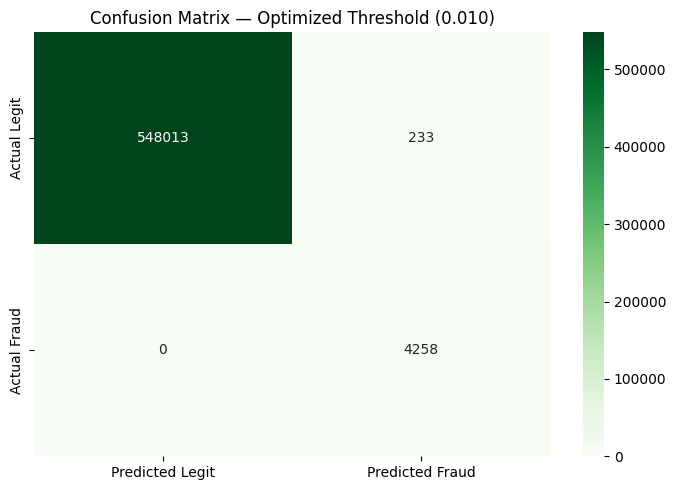

True  Positives (fraud caught):      4,258
False Negatives (fraud missed):      0
False Positives (legit flagged):     233
True  Negatives (legit cleared):     548,013

Recall (TPR):  1.0000  (fraud cases caught)
Precision:     0.9481  (of flagged, actually fraud)
TNR:           0.9996  (legit transactions correctly cleared)
FNR:           0.0000  (fraud cases missed)


In [14]:
# Confusion matrix at the optimized threshold
y_pred_opt = (y_proba >= best_thresh).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm_opt.ravel()

plt.figure(figsize=(7, 5))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
plt.title(f'Confusion Matrix — Optimized Threshold ({best_thresh:.3f})')
plt.tight_layout()
plt.show()

print(f"True  Positives (fraud caught):      {tp:,}")
print(f"False Negatives (fraud missed):      {fn:,}")
print(f"False Positives (legit flagged):     {fp:,}")
print(f"True  Negatives (legit cleared):     {tn:,}")
print(f"\nRecall (TPR):  {tp / (tp + fn):.4f}  (fraud cases caught)")
print(f"Precision:     {tp / (tp + fp):.4f}  (of flagged, actually fraud)")
print(f"TNR:           {tn / (tn + fp):.4f}  (legit transactions correctly cleared)")
print(f"FNR:           {fn / (fn + tp):.4f}  (fraud cases missed)")


## 9. Fraud Probability Distribution

Visualize how well the model separates fraud from legitimate transactions by looking at the predicted probability distributions.

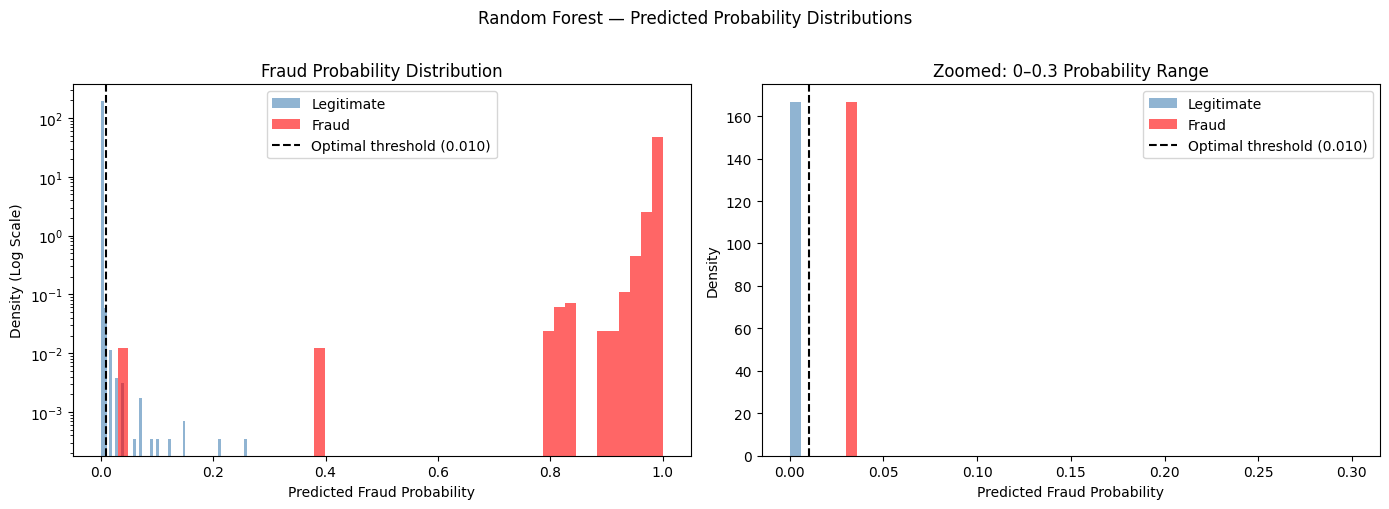

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution — log y-scale so both spikes are visible
axes[0].hist(y_proba[y_test == 0], bins=50, alpha=0.6, label='Legitimate', color='steelblue', density=True)
axes[0].hist(y_proba[y_test == 1], bins=50, alpha=0.6, label='Fraud',      color='red',       density=True)
axes[0].axvline(x=best_thresh, color='black', linestyle='--', label=f'Optimal threshold ({best_thresh:.3f})')
axes[0].set_yscale('log')
axes[0].set_xlabel('Predicted Fraud Probability')
axes[0].set_ylabel('Density (Log Scale)')
axes[0].set_title('Fraud Probability Distribution')
axes[0].legend()

# Zoom in on the 0–0.3 range to see separation near threshold
axes[1].hist(y_proba[y_test == 0], bins=50, alpha=0.6, label='Legitimate', color='steelblue', density=True, range=(0, 0.3))
axes[1].hist(y_proba[y_test == 1], bins=50, alpha=0.6, label='Fraud',      color='red',       density=True, range=(0, 0.3))
axes[1].axvline(x=best_thresh, color='black', linestyle='--', label=f'Optimal threshold ({best_thresh:.3f})')
axes[1].set_xlabel('Predicted Fraud Probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Zoomed: 0–0.3 Probability Range')
axes[1].legend()

plt.suptitle('Random Forest — Predicted Probability Distributions', y=1.01)
plt.tight_layout()
plt.show()


## 11. Sample Decision Tree

A Random Forest is an ensemble of 100 trees — we visualize one representative tree (tree index 0) truncated to depth 4 for readability. Each node shows the feature it splits on, the Gini impurity, and how many samples reached that node.

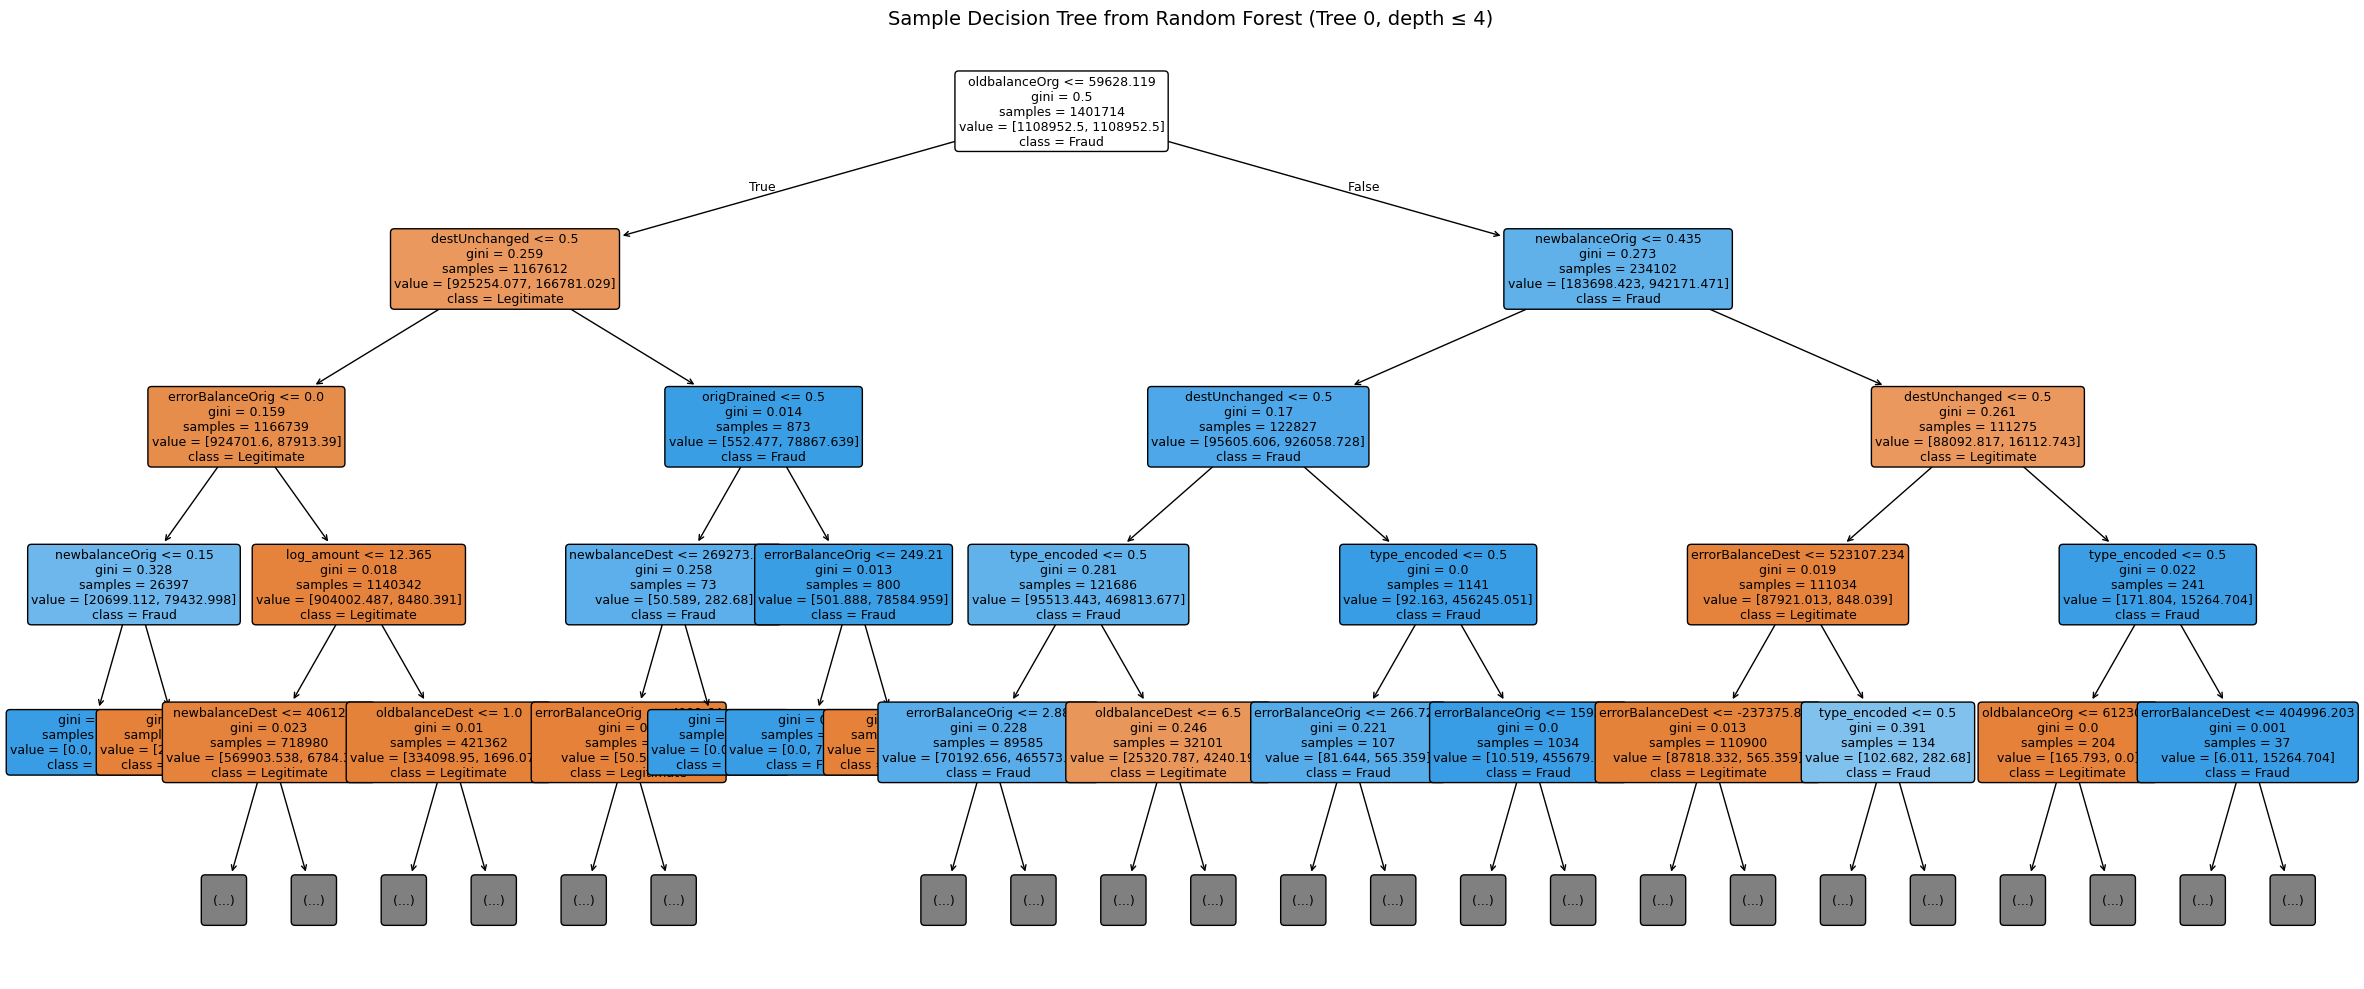

In [15]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    rf.estimators_[0],
    max_depth=4,
    feature_names=FEATURES,
    class_names=['Legitimate', 'Fraud'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
plt.title('Sample Decision Tree from Random Forest (Tree 0, depth ≤ 4)', fontsize=14)
plt.tight_layout()
plt.show()
